Notebook for plotting and analyzing the results of output netcdf files from each model

In [1]:
import os
import sys
# import torch
# import logging
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

# import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# from scipy.special import gamma, gammaln

# import copy
import datetime
import yaml

import importlib

# import tqdm

In [4]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn

In [9]:
model_path = "/export/breeze1/mhayman/aerosol_poly_nn/models/"

In [334]:
file_name_lst = [
    # "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310.nc"
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_5error.nc", # 6 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_10error.nc", # 6 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_20error.nc", # 6 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_30error.nc", # 6 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_50error.nc", # 6 beta, 2 alpha all refractive indices
    # "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260310T065310_200error.nc", # 6 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260311T110300_5error.nc", # 3 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260311T110300_10error.nc", # 3 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260311T110300_20error.nc", # 3 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260311T110300_30error.nc", # 3 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260311T110300_50error.nc", # 3 beta, 2 alpha all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260324T070054_5error.nc", # 1 beta, 1 alpha 355 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260324T070054_10error.nc", # 1 beta, 1 alpha 355 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260324T070054_20error.nc", # 1 beta, 1 alpha 355 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260324T070054_30error.nc", # 1 beta, 1 alpha 355 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260324T070054_50error.nc", # 1 beta, 1 alpha 355 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260327T080000_5error.nc", # 1 beta, 1 alpha 532 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260327T080000_10error.nc", # 1 beta, 1 alpha 532 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260327T080000_20error.nc", # 1 beta, 1 alpha 532 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260327T080000_30error.nc", # 1 beta, 1 alpha 532 nm, all refractive indices
    "/export/breeze1/mhayman/aerosol_poly_nn/output_analysis/full_aggregate_analysis_20260327T080000_50error.nc", # 1 beta, 1 alpha 532 nm, all refractive indices
]

In [335]:
model_descr_dct = {
    "20260310T065310":r'2$\alpha$ 6$\beta$',
    "20260311T110300":r'2$\alpha$ 3$\beta$',
    "20260324T070054":'355 nm', 
    "20260327T080000":'532 nm'
}
model_color_dct = {
    "20260310T065310":'tab:blue',
    "20260311T110300":'tab:red',
    "20260324T070054":'tab:purple', 
    "20260327T080000":'tab:green'
}
model_marker_dct = {
    "20260310T065310":'o',
    "20260311T110300":'s',
    "20260324T070054":'D', 
    "20260327T080000":'v'
}


In [336]:
try:
    for ds in nc_data_lst:
        ds.close()
except NameError:
    pass

In [337]:
nc_data_lst = []
x_rescale_lst = []
y_rescale_lst = []
model_lst = []
ens_width_lst = []
for file in file_name_lst:
    nc_data_lst.append(xr.open_dataset(file))
    model_lst.append(nc_data_lst[-1].attrs['model'])
    ens_width_lst.append(nc_data_lst[-1].attrs['ensemble_width'])
    
    # get the rescaling data
    conf_reload, model_reload = evid_nn.load_poly_nn_model(nc_data_lst[-1].attrs['model'],name_str='hyper_best',device='cpu',path=model_path)
    x_scaler = evid_nn.rescale(0,1)
    x_scaler.set_config(**conf_reload['save_model']['x_scaler'])
    y_scaler = evid_nn.rescale(0,1)
    y_scaler.set_config(**conf_reload['save_model']['y_scaler'])

    x_rescale_lst.append(x_scaler)
    y_rescale_lst.append(y_scaler)

loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aerosol_poly_nn/models/
loading model from 
/export/breeze1/mhayman/aero

In [338]:
x_scaler.gain.tolist()

[[19.485613648988213, 20.222721193653214]]

In [339]:
act_data_ln_lst = []
centroid_data_ln_lst = []
centroid_ens_data_ln_lst = []

hr_lst = []
hr_ens_lst = []
hn_lst = []
hn_ens_lst = []

for m_idx, y_scaler in enumerate(y_rescale_lst):
    act_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_act'],nc_data_lst[m_idx]['r_act']],axis=1))
    centroid_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_centroid'],nc_data_lst[m_idx]['r_centroid']],axis=1))
    centroid_ens_data_ln = y_scaler.unscale(np.stack([nc_data_lst[m_idx]['n_ens_centroid'],nc_data_lst[m_idx]['r_ens_centroid']],axis=1))

    act_data_ln_lst.append(act_data_ln)
    centroid_data_ln_lst.append(centroid_data_ln)
    centroid_ens_data_ln_lst.append(centroid_ens_data_ln)

    # hr = np.histogram(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
    hr = np.histogram((act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))
    hr_ens = np.histogram((act_data_ln[:,1]-centroid_ens_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))


    # hn = np.histogram(np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
    hn = np.histogram((act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))
    hn_ens = np.histogram((act_data_ln[:,0]-centroid_ens_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

    hr_lst.append(hr)
    hr_ens_lst.append(hr_ens)
    hn_lst.append(hn)
    hn_ens_lst.append(hn_ens)

In [340]:
nc_data_lst[-3]['ens_std_width'].values

array([0.00406357, 0.00391546])

In [341]:
nc_data_lst[-2]['ens_std_width'].values

array([0.00584756, 0.00563442])

In [342]:
nc_data_lst[-1]['ens_std_width'].values

array([0.00903699, 0.00870759])

In [343]:
nc_data_lst[-1].attrs

{'model': '20260327T080000',
 'ensemble_width': np.float64(0.5),
 'ensemble_size': np.int64(25),
 'sample_interval': np.int64(20),
 'file_creation_date': '2026-04-23 05:29:11'}

In [344]:
# plt.figure()
# plt.scatter(centroid_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),act_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),alpha=0.3)
# plt.scatter(centroid_ens_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),act_data_ln_lst[-1][:,1]*np.log10(np.exp(1)),alpha=0.3)

# plt.figure()
# plt.scatter(nc_data_lst[-1]['r_centroid'],nc_data_lst[-1]['r_act'])
# plt.scatter(nc_data_lst[-1]['r_ens_centroid'],nc_data_lst[-1]['r_act'])

In [345]:
# hist_out_label
hist_act_data_ln = y_rescale_lst[-1].unscale(nc_data_lst[0]['hist_out_label'].values)
hr_prior = np.histogram((act_data_ln[:,1]-np.mean(hist_act_data_ln[:,1]))*np.log10(np.exp(1)),bins=np.linspace(-1,1,100))

hn_prior = np.histogram((act_data_ln[:,0]-np.mean(hist_act_data_ln[:,0]))*np.log10(np.exp(1)),bins=np.linspace(-2,2,100))

In [346]:
# nc_data['r_ens_interval'].values[0:10]-nc_data['r_interval'].values[0:10]

In [347]:
# total histogram of training/test/validation data
h_part_total = np.histogram2d(nc_data_lst[0]['hist_out_label'].values[:,1],nc_data_lst[0]['hist_out_label'].values[:,0],bins=np.linspace(0,1,500))

percentile_lst = nc_data_lst[0]['percentiles'].values
r_interval_arr_lst = []
n_interval_arr_lst = []
r_ens_interval_arr_lst = []
n_ens_interval_arr_lst = []
for nc_data in nc_data_lst:
    r_interval_arr_lst.append(nc_data['r_interval'].values)
    n_interval_arr_lst.append(nc_data['n_interval'].values)
    r_ens_interval_arr_lst.append(nc_data['r_ens_interval'].values)
    n_ens_interval_arr_lst.append(nc_data['n_ens_interval'].values)

r_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=0))/np.sum(h_part_total[0])
n_cdf_prior = np.cumsum(np.sum(h_part_total[0],axis=1))/np.sum(h_part_total[0])

r_tot_interval = np.interp(percentile_lst,r_cdf_prior,0.5*(h_part_total[1][:-1]+h_part_total[1][1:]))
n_tot_interval = np.interp(percentile_lst,n_cdf_prior,0.5*(h_part_total[2][:-1]+h_part_total[2][1:]))

y_scaler = y_rescale_lst[-1]

percentile_prior_ln_lst = []
for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
    print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
    percentile_prior_ln_1 = y_scaler.unscale(np.array([[n_tot_interval[i_per]],[r_tot_interval[i_per]]]).T)
    percentile_prior_ln_2 = y_scaler.unscale(np.array([[n_tot_interval[-1-i_per]],[r_tot_interval[-1-i_per]]]).T)
    percentile_prior_ln_lst.append([percentile_prior_ln_1,percentile_prior_ln_2])

0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8


In [348]:
percentile_data_ln_lst_lst = []
percentile_ens_data_ln_lst_lst = []
percentile_model_sets = []
for m_idx, y_scaler in enumerate(y_rescale_lst):
    percentile_data_ln_lst = []
    percentile_ens_data_ln_lst = []
    percentile_sets = []
    for i_per in range(r_interval_arr_lst[m_idx].shape[1]//2):
        print(f"{percentile_lst[i_per]} to {percentile_lst[-1-i_per]}")
        percentile_data_ln_1 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,i_per],r_interval_arr_lst[m_idx][:,i_per]],axis=1))
        percentile_data_ln_2 = y_scaler.unscale(np.stack([n_interval_arr_lst[m_idx][:,-1-i_per],r_interval_arr_lst[m_idx][:,-1-i_per]],axis=1))
        percentile_data_ln_lst.append([percentile_data_ln_1,percentile_data_ln_2])

        percentile_data_ln_1 = y_scaler.unscale(np.stack([n_ens_interval_arr_lst[m_idx][:,i_per],r_ens_interval_arr_lst[m_idx][:,i_per]],axis=1))
        percentile_data_ln_2 = y_scaler.unscale(np.stack([n_ens_interval_arr_lst[m_idx][:,-1-i_per],r_ens_interval_arr_lst[m_idx][:,-1-i_per]],axis=1))
        percentile_ens_data_ln_lst.append([percentile_data_ln_1,percentile_data_ln_2])
        
        percentile_sets.append([percentile_lst[i_per],percentile_lst[-1-i_per]])

    percentile_data_ln_lst_lst.append(percentile_data_ln_lst)
    percentile_ens_data_ln_lst_lst.append(percentile_ens_data_ln_lst)
    percentile_model_sets.append(percentile_sets)

0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8
0.01 to 0.99
0.05 to 0.95
0.1 to 0.9
0.2 to 0.8


In [350]:
# custom_label_lst = [r'2$\alpha$ 6$\beta$',r'2$\alpha$ 3$\beta$','355 nm', '532 nm']
custom_label_lst = [r'5% error',r'10% error',r'20% error',r'30% error','50% error',]
custom_label_lst += [r'5% error',r'10% error',r'20% error',r'30% error','50% error',]
custom_label_lst += [r'5% error',r'10% error',r'20% error',r'30% error','50% error',]
custom_label_lst += [r'5% error',r'10% error',r'20% error',r'30% error','50% error',]

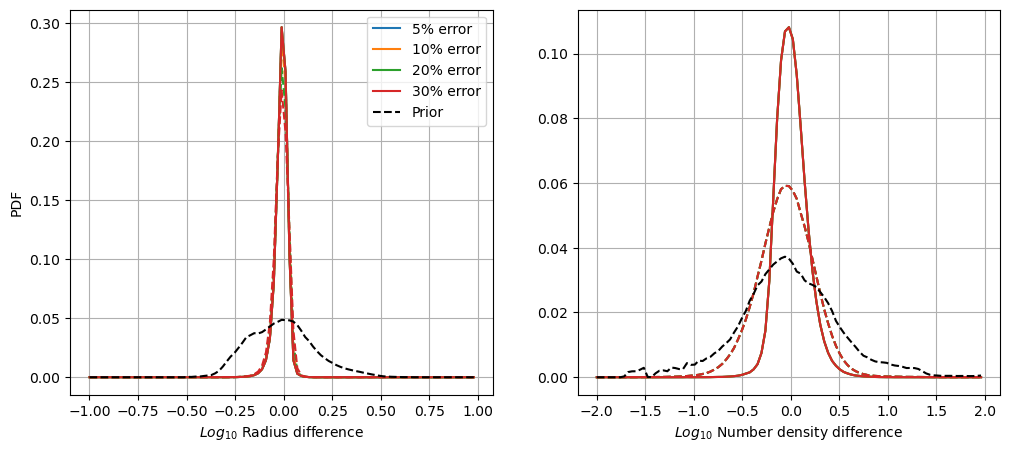

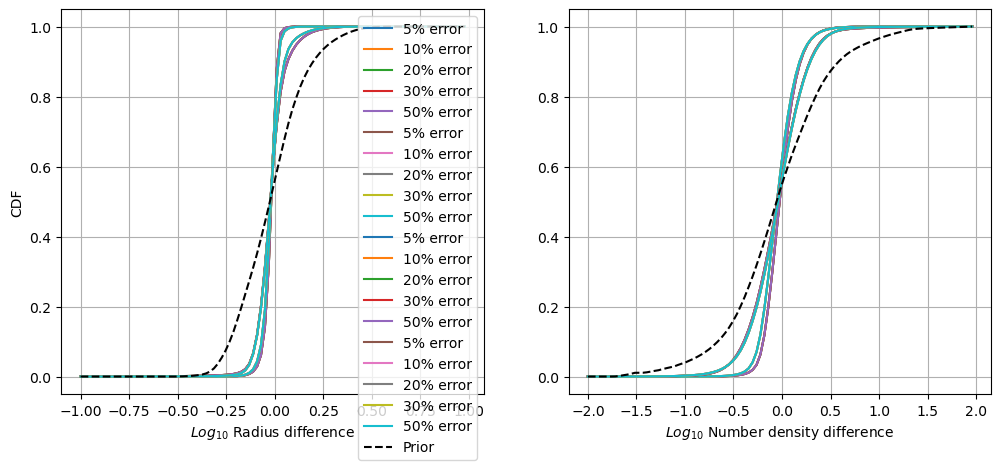

In [351]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt_lst = [0,1,2,3]
for m_idx, hr in enumerate(hr_lst):
    if m_idx in plt_lst:
        hr_ens = hr_ens_lst[m_idx]
        # label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
        label = custom_label_lst[m_idx]
        ax[0].plot(hr[1][:-1],hr[0]/np.sum(hr[0]),label=label)
        ax[0].plot(hr_ens[1][:-1],hr_ens[0]/np.sum(hr_ens[0]),color='C%d'%m_idx,linestyle='--')
    
    
        hn = hn_lst[m_idx]
        ax[1].plot(hn[1][:-1],hn[0]/np.sum(hn[0]),label=label)
        ax[1].plot(hn_ens[1][:-1],hn_ens[0]/np.sum(hn_ens[0]),color='C%d'%m_idx,linestyle='--')

ax[0].plot(hr_prior[1][:-1],hr_prior[0]/np.sum(hr_prior[0]),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("PDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],hn_prior[0]/np.sum(hn_prior[0]),label="Prior",color='k',linestyle='--')
ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)

fig,ax = plt.subplots(1,2,figsize=(12,5))
for m_idx, hr in enumerate(hr_lst):
    # label = ', '.join(label_param_lst_lst[m_idx])+": "+", ".join(label_wl_lst_lst[m_idx])
    label = custom_label_lst[m_idx]
    ax[0].plot(hr[1][:-1],np.cumsum(hr[0]/np.sum(hr[0])),label=label)
    

    hn = hn_lst[m_idx]
    ax[1].plot(hn[1][:-1],np.cumsum(hn[0]/np.sum(hn[0])),label=label)

ax[0].plot(hr_prior[1][:-1],np.cumsum(hr_prior[0]/np.sum(hr_prior[0])),label="Prior",color='k',linestyle='--')

ax[0].set_xlabel('$Log_{10}$ Radius difference')
ax[0].grid(visible=True)
ax[0].set_ylabel("CDF")
ax[0].legend()

ax[1].plot(hn_prior[1][:-1],np.cumsum(hn_prior[0]/np.sum(hn_prior[0])),label="Prior",color='k',linestyle='--')

ax[1].set_xlabel('$Log_{10}$ Number density difference')
ax[1].grid(visible=True)

5-95 %
5% error
90.000000%
No Noise: 0.6003154093801566
Ensemble: 0.6473126500362898
5-95 %
10% error
90.000000%
No Noise: 0.6003154093801566
Ensemble: 0.7796110027226171
5-95 %
20% error
90.000000%
No Noise: 0.6003154093801566
Ensemble: 1.04218096959006
5-95 %
30% error
90.000000%
No Noise: 0.6003154093801566
Ensemble: 1.2663211487607597
5-95 %
50% error
90.000000%
No Noise: 0.6003154093801566
Ensemble: 1.6272095836422522
5-95 %
5% error
90.000000%
No Noise: 0.6627787550459745
Ensemble: 0.715530718974961
5-95 %
10% error
90.000000%
No Noise: 0.6627787550459745
Ensemble: 0.8434836460009933
5-95 %
20% error
90.000000%
No Noise: 0.6627787550459745
Ensemble: 1.1810222104616772
5-95 %
30% error
90.000000%
No Noise: 0.6627787550459745
Ensemble: 1.6207777213676227
5-95 %
50% error
90.000000%
No Noise: 0.6627787550459745
Ensemble: 2.2262261182536305
5-95 %
5% error
90.000000%
No Noise: 0.9803800380003796
Ensemble: 0.9808566276575511
5-95 %
10% error
90.000000%
No Noise: 0.9803800380003796
Ens

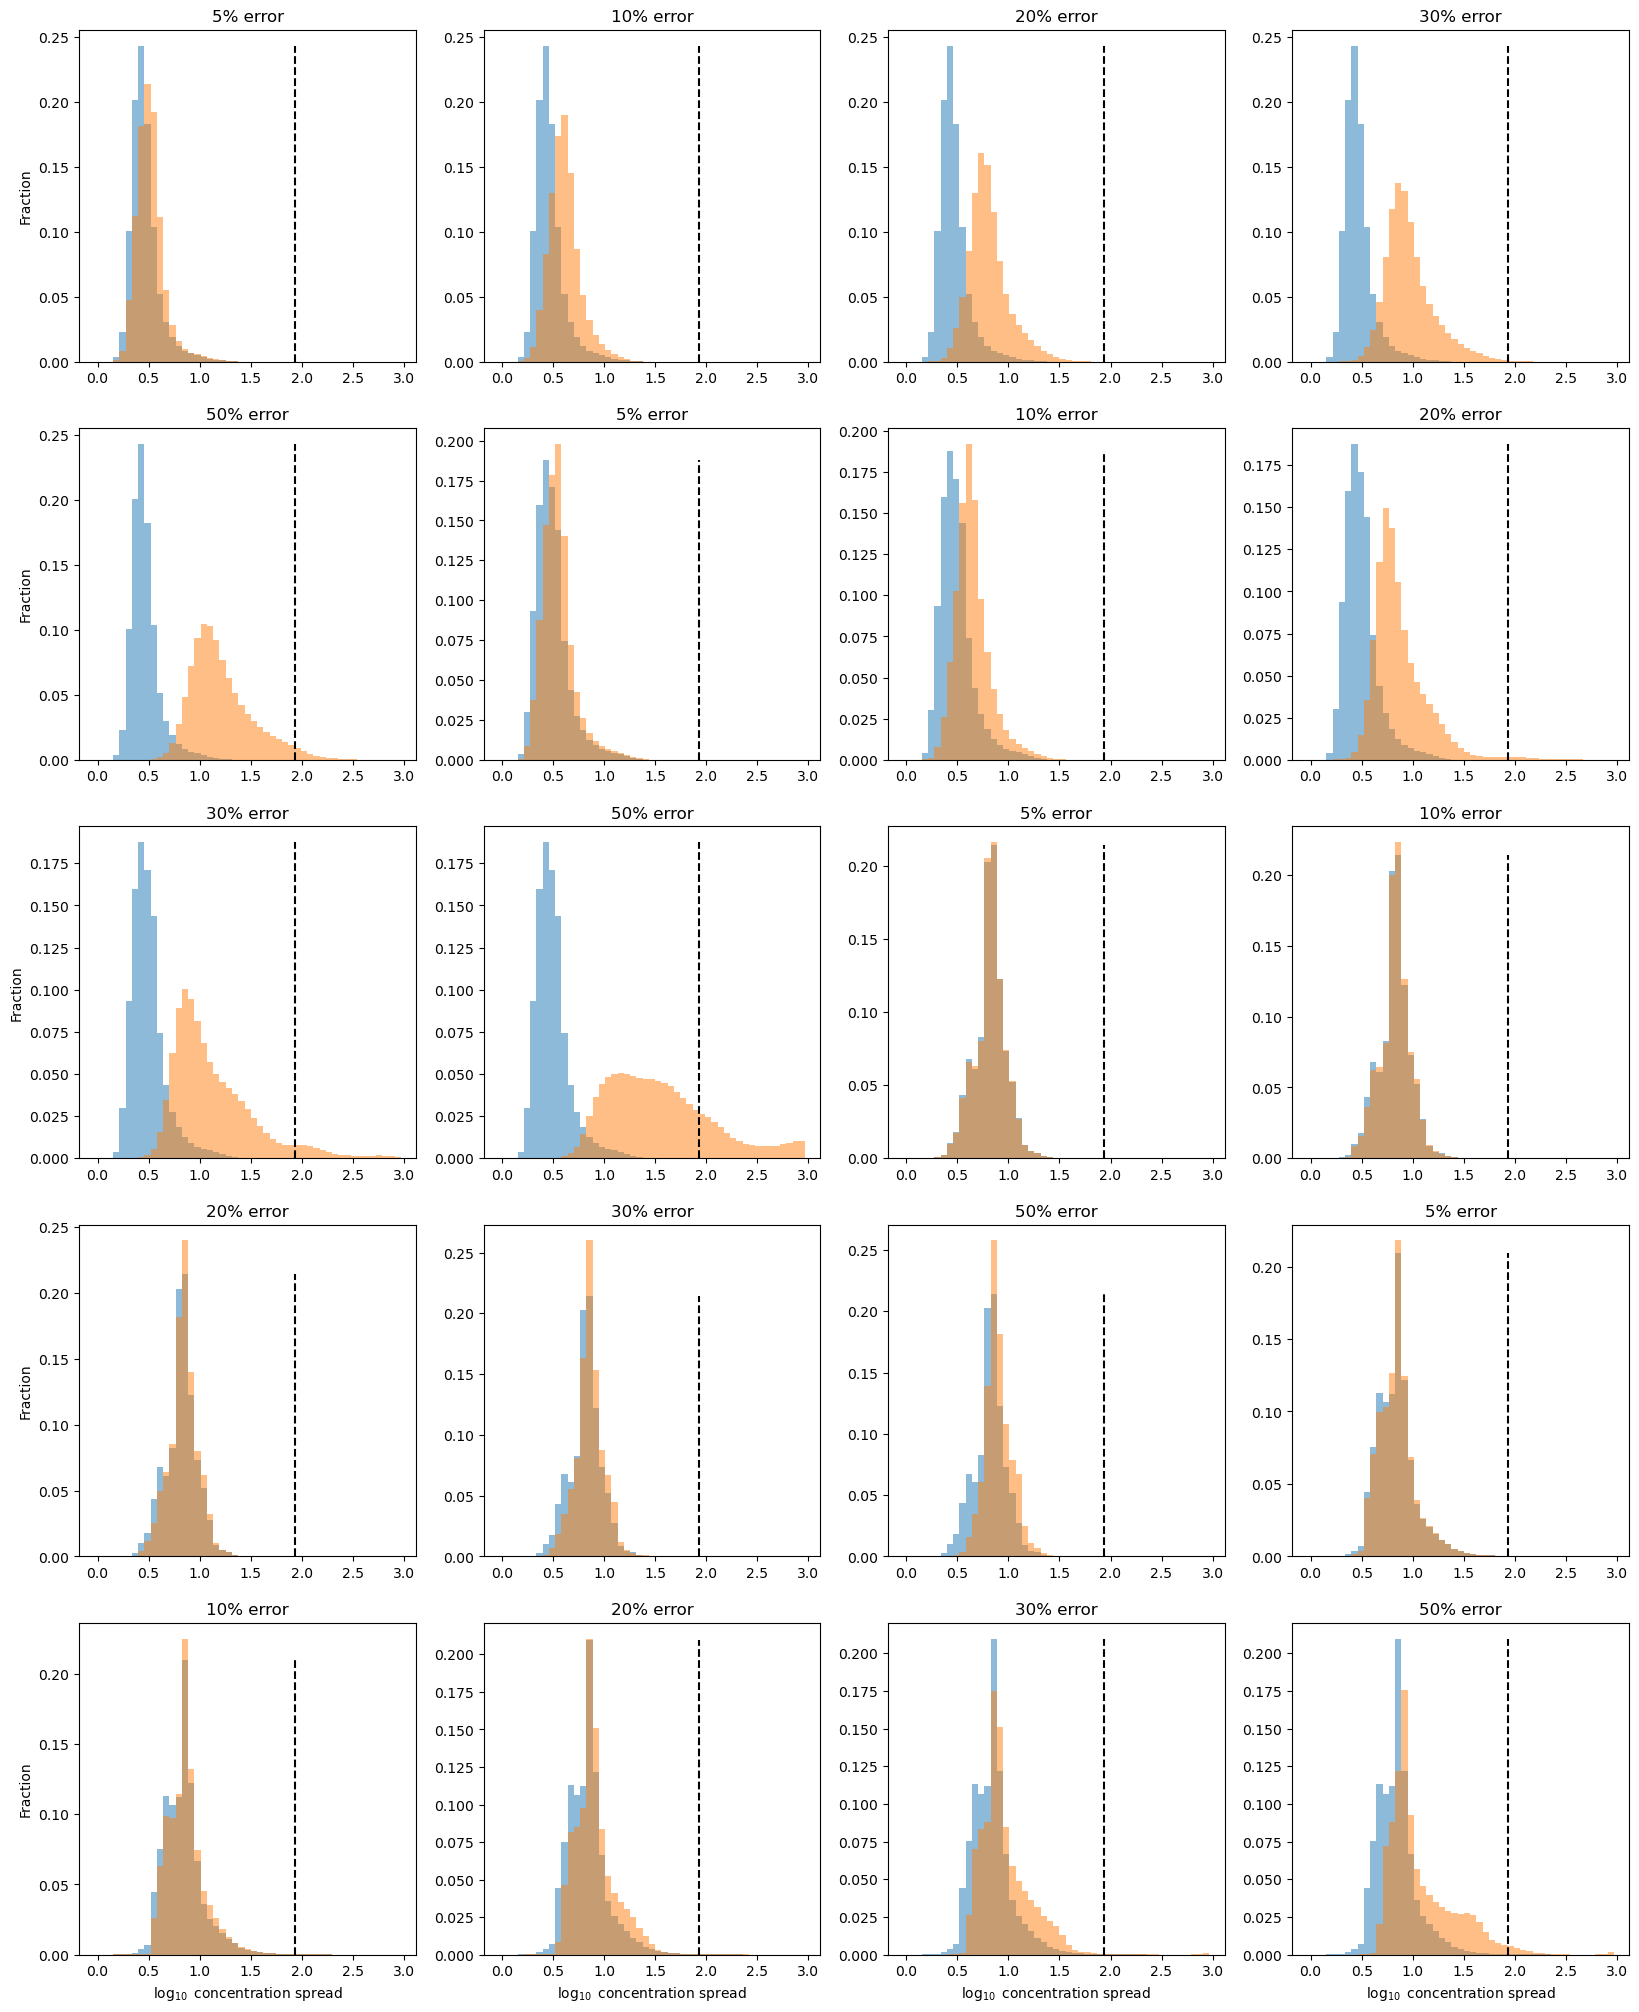

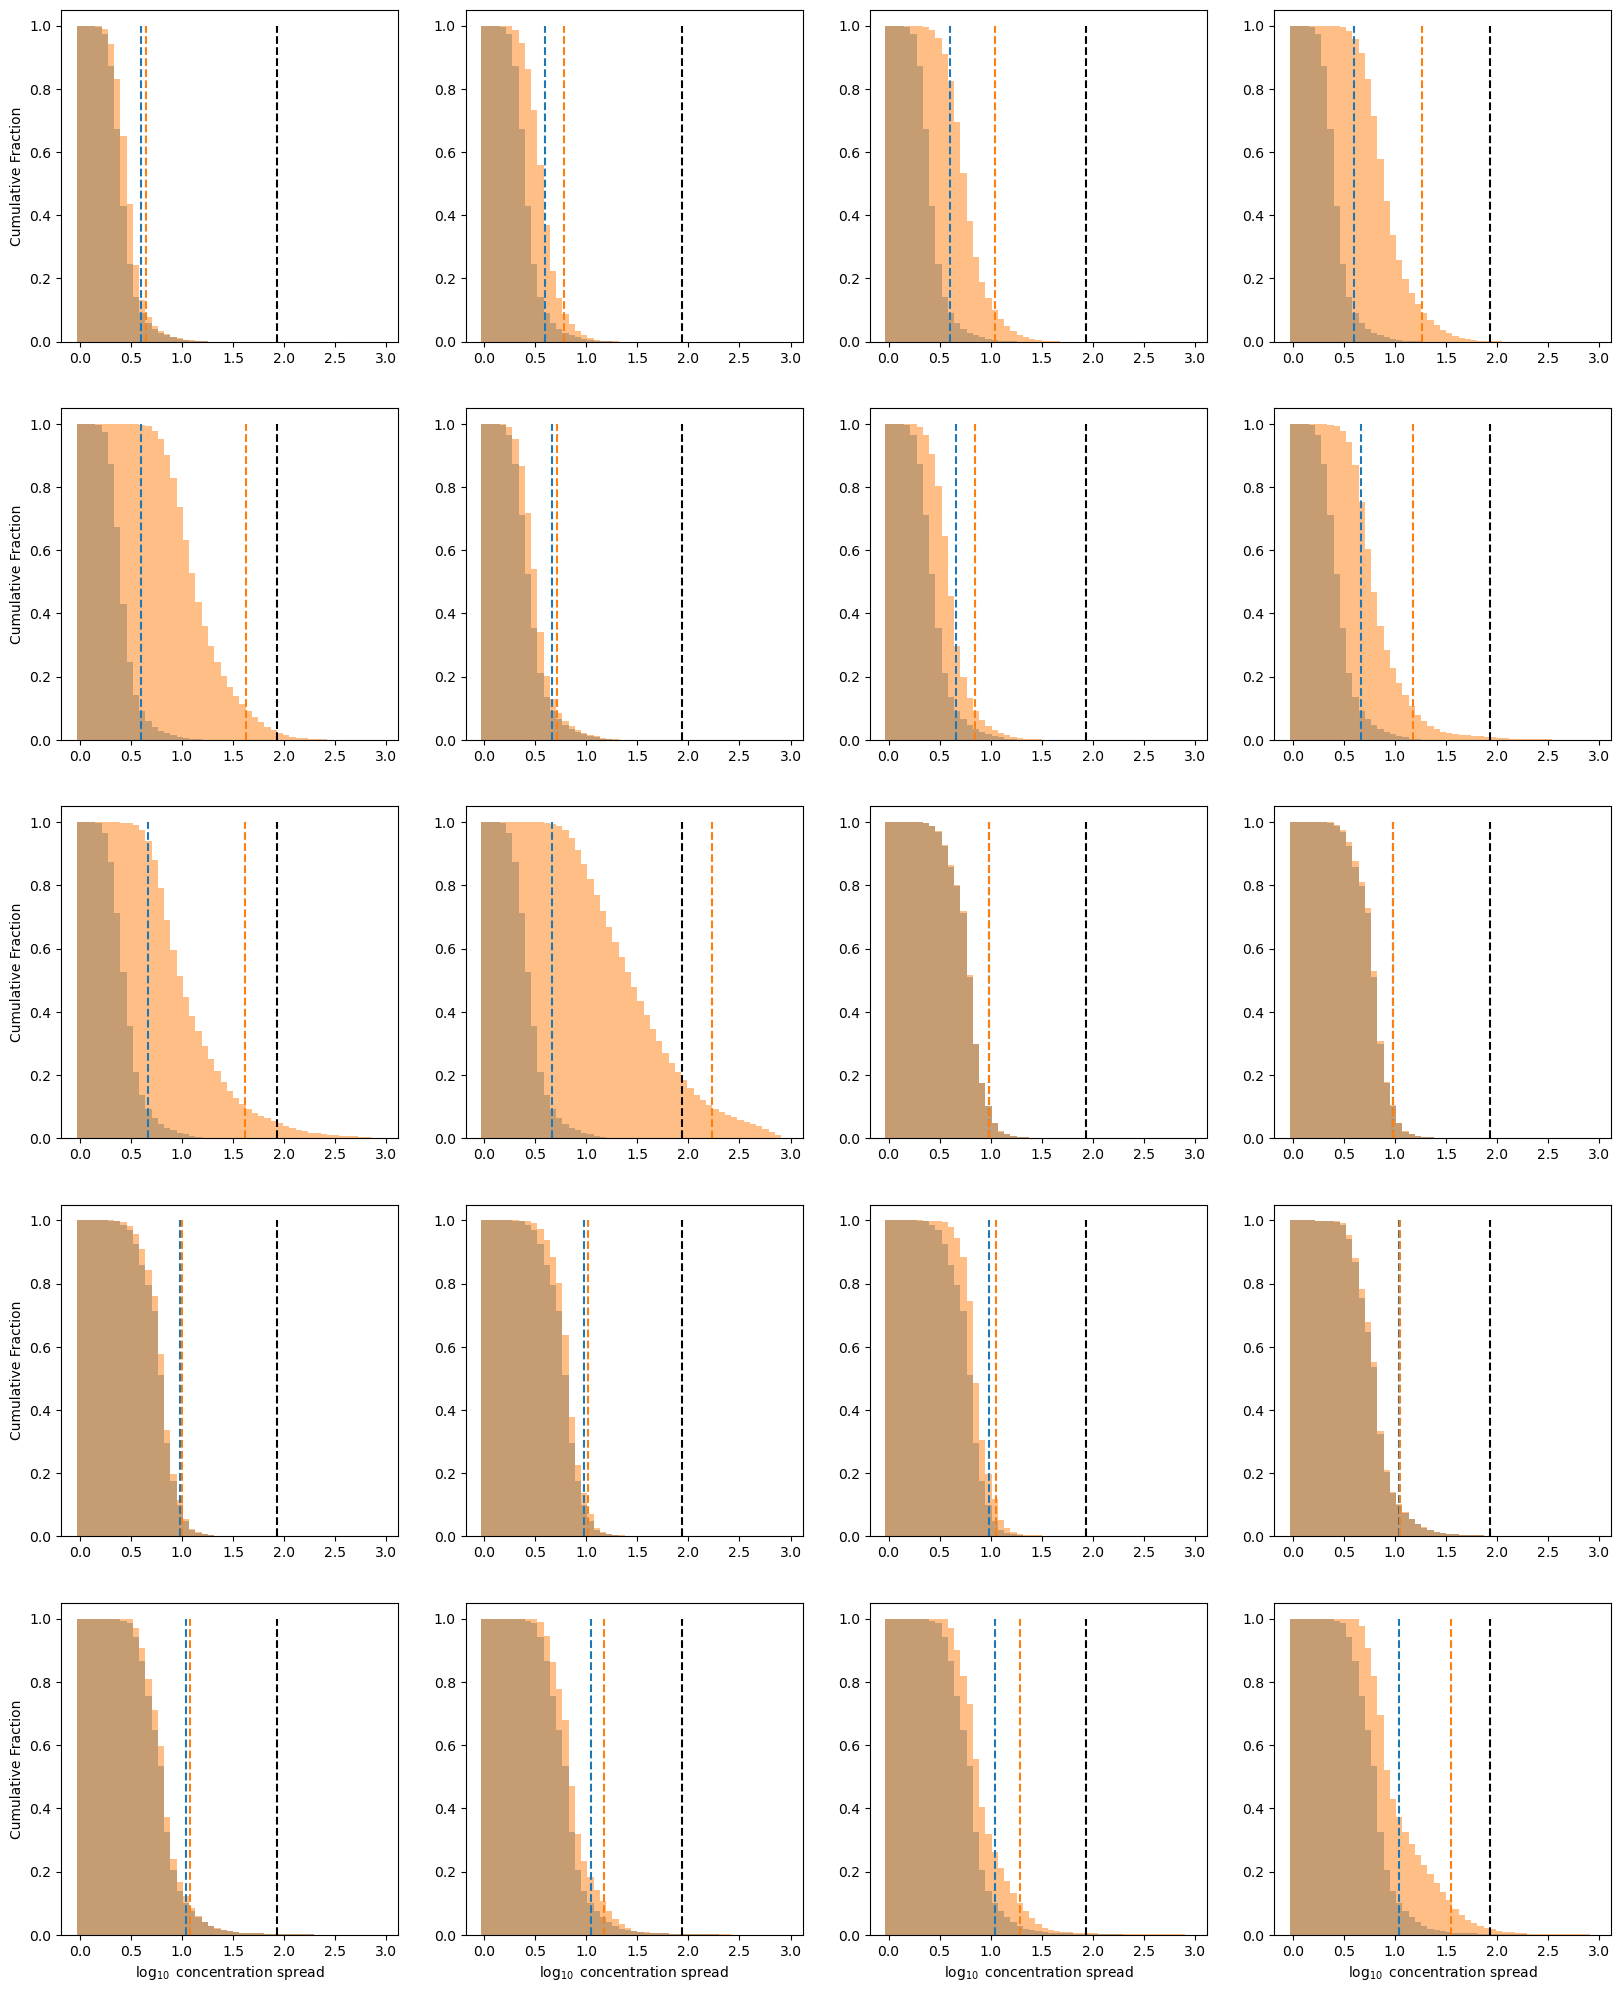

In [352]:
percentile_idx = 1
# plt_lst = [0,1,2,3,4,5,6,7]
plt_lst = np.arange(len(nc_data_lst))
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))

conc_log_wid_dct = {}
conc_log_error_dct = {}

fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()

fig_cdf,ax_lst_cdf = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst_cdf = ax_lst_cdf.ravel()

# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    model_str = model_lst[pidx]
    if model_str not in conc_log_wid_dct:
        conc_log_wid_dct[model_str] = []
        conc_log_error_dct[model_str] = []
        
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_ens_delta = percentile_ens_delta[:,0]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,3,50))
    hists_ens = np.histogram(percentile_ens_delta,
                bins=np.linspace(0,3,50))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]),alpha=0.5)
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(hists_ens[1]),alpha=0.5)

    ax.plot(2*[prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ concentration spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    # ax.set_xlim([0,20])
    # ax.set_ylim([0,3])

    contain_lim = 1-0.90
    h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
    h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
    cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
    cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])
    ax = ax_lst_cdf[m_idx]
    ax.bar(x_axis_plt,h_cdf,width=np.diff(hists[1]),alpha=0.5)
    ax.bar(x_axis_plt,h_cdf_ens,width=np.diff(hists_ens[1]),alpha=0.5)

    ax.plot(2*[prior_percentile_delta[0,0]],[0,1],'k--')
    ax.plot(2*[cdf_lim],[0,1],'C0--')
    ax.plot(2*[cdf_lim_ens],[0,1],'C1--')
    print(title + f"\n{100*(1-contain_lim):02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]}")
    if len(conc_log_wid_dct[model_str]) == 0:
        conc_log_wid_dct[model_str].append(cdf_lim.item())
        conc_log_error_dct[model_str].append(0.0)
    conc_log_wid_dct[model_str].append(cdf_lim_ens.item())
    conc_log_error_dct[model_str].append(ens_width_lst[pidx])

    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'$\log_{10}$ concentration spread')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Cumulative Fraction')

5-95 %
5% error
90.000000%
No Noise: 0.6195007976944059
Ensemble: 0.665062328926911
5-95 %
10% error
90.000000%
No Noise: 0.6195007976944059
Ensemble: 0.7985432453070851
5-95 %
20% error
90.000000%
No Noise: 0.6195007976944059
Ensemble: 1.0660774874548982
5-95 %
30% error
90.000000%
No Noise: 0.6195007976944059
Ensemble: 1.2931204802323177
5-95 %
50% error
90.000000%
No Noise: 0.6195007976944059
Ensemble: 1.6681592938225005
5-95 %
5% error
90.000000%
No Noise: 0.6822618341145918
Ensemble: 0.7338601092096331
5-95 %
10% error
90.000000%
No Noise: 0.6822618341145918
Ensemble: 0.8634636499199557
5-95 %
20% error
90.000000%
No Noise: 0.6822618341145918
Ensemble: 1.206734346460028
5-95 %
30% error
90.000000%
No Noise: 0.6822618341145918
Ensemble: 1.6684679334916863
5-95 %
50% error
90.000000%
No Noise: 0.6822618341145918
Ensemble: 2.5037623240017135
5-95 %
5% error
90.000000%
No Noise: 1.00182965765144
Ensemble: 1.0031425431789753
5-95 %
10% error
90.000000%
No Noise: 1.00182965765144
Ensemb

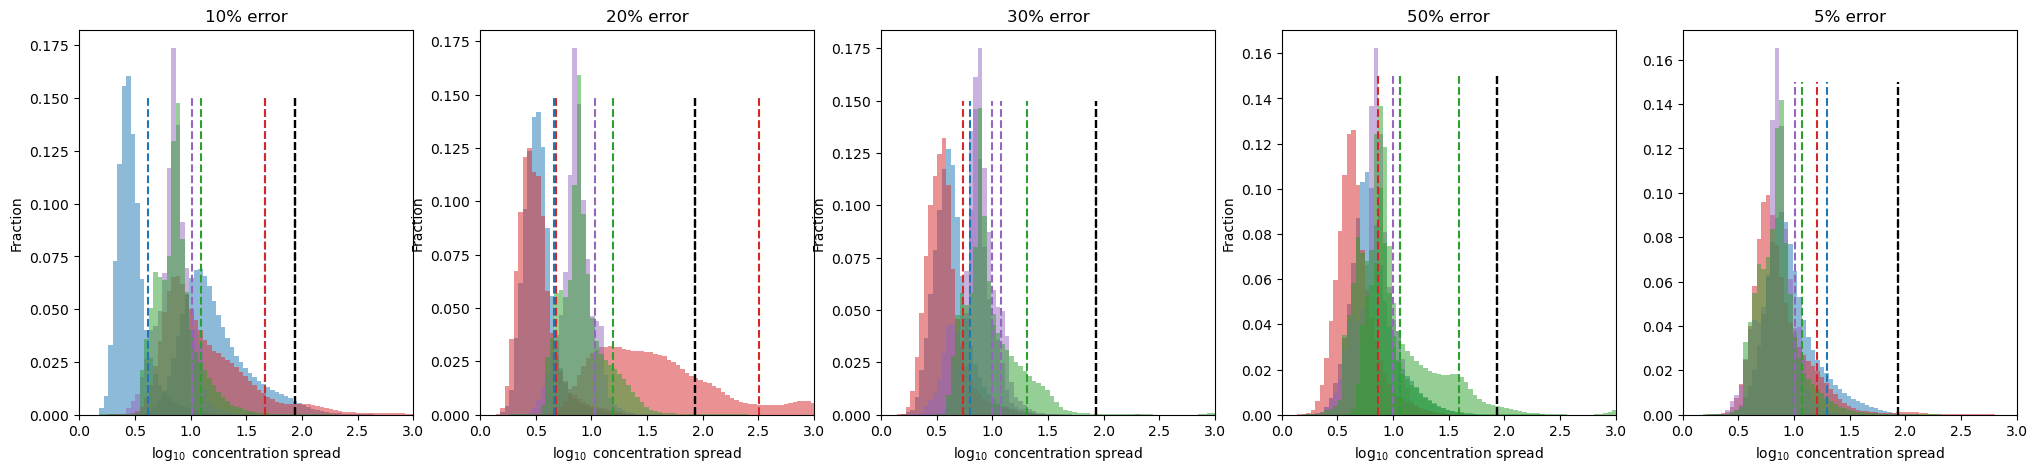

In [353]:
percentile_idx = 1
# plt_lst = [0,1,2,3,4,5,6,7]
plt_lst = np.arange(len(nc_data_lst))
n_col = 5
n_row = 1
# n_row = int(np.ceil(len(plt_lst)/n_col))

line_height = 0.15
x_lim = 3

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))

conc_log_wid_dct = {}
conc_log_error_dct = {}

fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()

ax_idx = 0
for m_idx, pidx in enumerate(plt_lst):
    model_str = model_lst[pidx]
    if model_str not in conc_log_wid_dct:
        conc_log_wid_dct[model_str] = []
        conc_log_error_dct[model_str] = []
        plot_zero_error=True
        
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_ens_delta = percentile_ens_delta[:,0]
    
    ax = ax_lst[ax_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,4,100))
    hists_ens = np.histogram(percentile_ens_delta,
                bins=np.linspace(0,4,100))
    # x_axis_plt = 10**(hists[1][:-1])
    x_axis_plt = hists[1][:-1]
    if plot_zero_error:
        ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]),alpha=0.5,facecolor=model_color_dct[model_str])
        ax.plot(2*[prior_percentile_delta[0,0]],[0,line_height],'k--')
        ax.set_ylabel(r'Fraction')
        ax.set_xlabel(r'$\log_{10}$ concentration spread')
        ax.set_title(r'0% error')
        ax.set_xlim([0, x_lim])
        ax_idx = (ax_idx+1)%n_col
        ax = ax_lst[ax_idx]
    
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(hists_ens[1]),alpha=0.5,facecolor=model_color_dct[model_str])

    ax.plot(2*[prior_percentile_delta[0,0]],[0,line_height],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    ax.set_xlabel(r'$\log_{10}$ concentration spread')
    ax.set_xlim([0, x_lim])
    
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)

    contain_lim = 1-0.90
    h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
    h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
    cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
    cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])

    if plot_zero_error:
        ax_lst[ax_idx-1].plot(2*[cdf_lim],[0,line_height],'--',color=model_color_dct[model_str])
    ax.plot(2*[cdf_lim_ens],[0,line_height],'--',color=model_color_dct[model_str])
        
    print(title + f"\n{100*(1-contain_lim):02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]}")
    if len(conc_log_wid_dct[model_str]) == 0:
        conc_log_wid_dct[model_str].append(cdf_lim.item())
        conc_log_error_dct[model_str].append(0.0)
    conc_log_wid_dct[model_str].append(cdf_lim_ens.item())
    conc_log_error_dct[model_str].append(ens_width_lst[pidx])

    ax_idx = (ax_idx+1)%n_col
    plot_zero_error = False

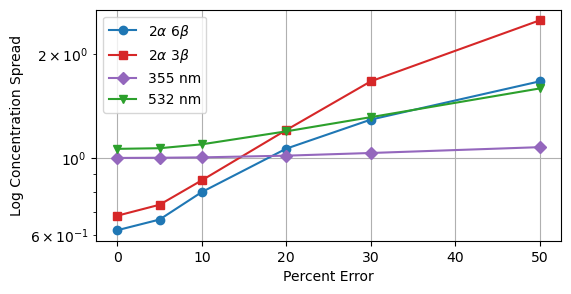

In [354]:
fig,ax = plt.subplots(1,1,figsize=(6,3))

for model_str in conc_log_wid_dct:
    y_data = np.asarray(conc_log_wid_dct[model_str], dtype=float)
    x_data = np.asarray(conc_log_error_dct[model_str], dtype=float)
    label = model_descr_dct[model_str]
    plt_color = model_color_dct[model_str]
    plt_marker = model_marker_dct[model_str]
    ax.plot(x_data*100,y_data,'-',label=label,color=plt_color,marker=plt_marker)

ax.set_yscale('log')
ax.grid(visible=True)
ax.set_xlabel("Percent Error")
ax.set_ylabel("Log Concentration Spread")
ax.legend()
    
    

In [355]:
# # percentile_idx = 1
# # plt_lst = [0,1,2,]
# n_col = 4
# # n_row = int(np.ceil(len(hcmb_lst)/n_col))
# n_row = int(np.ceil(len(plt_lst)/n_col))

# conc_log_wid_dct = {}
# conc_log_error_dct = {}

# prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


# fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst = ax_lst.ravel()

# fig_cdf,ax_lst_cdf = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst_cdf = ax_lst_cdf.ravel()

# # for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
# for m_idx, pidx in enumerate(plt_lst):
#     model_str = model_lst[pidx]
#     if model_str not in conc_log_wid_dct:
#         conc_log_wid_dct[model_str] = []
#         conc_log_error_dct[model_str] = []
    
#     centroid_data_ln = centroid_data_ln_lst[pidx]
#     act_data_ln = act_data_ln_lst[pidx]
#     percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
#     percentile_delta = percentile_delta[:,0]
#     percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
#     percentile_ens_delta = percentile_ens_delta[:,0]
#     ax = ax_lst[m_idx]
#     hists = np.histogram(percentile_delta,
#                 bins=np.linspace(0,3,50))
#     hists_ens = np.histogram(percentile_ens_delta,
#                 bins=np.linspace(0,3,50))

#     x_axis_plt0 = 10**hists[1]
#     # x_axis_plt0 = (10**(hists[1]-1))/(1+10**(hists[1]))
#     x_axis_plt = x_axis_plt0[:-1] #(1-10**(hists[1][:-1]))/(1+10**(hists[1][:-1]))
#     # x_axis_plt = 10**(hists[1][:-1])
#     # x_axis_plt = hists[1][:-1]
#     ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(x_axis_plt0),alpha=0.5)
#     ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(x_axis_plt0),alpha=0.5)

#     ax.plot(2*[10**prior_percentile_delta[0,0]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

#     print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

#     # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
#     # x_ax_lim = ax.get_xlim()
#     # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
#     #         [prior_percentile_delta[0,0]]*2,
#     #         'k--')
#     # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
#     # ax.set_xscale('log')
#     # ax.set_yscale('log')
#     # if m_idx//n_col == 1:
#     if m_idx//n_col == n_row-1:
#         ax.set_xlabel(r'relative spread in concentration')
#     if m_idx%n_col == 0:
#         ax.set_ylabel(r'Fraction')
#     # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
#     title = custom_label_lst[pidx]
#     ax.set_title(title)
#     ax.set_xlim([0,20])
#     # ax.set_ylim([0,3])

#     contain_lim = 1-0.90
#     h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
#     h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
#     cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
#     cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])
#     ax = ax_lst_cdf[m_idx]
#     ax.bar(x_axis_plt,h_cdf,width=np.diff(x_axis_plt0),alpha=0.5)
#     ax.bar(x_axis_plt,h_cdf_ens,width=np.diff(x_axis_plt0),alpha=0.5)

#     ax.plot(2*[10**prior_percentile_delta[0,0]],[0,1],'k--')
#     ax.plot(2*[cdf_lim],[0,1],'C0--')
#     ax.plot(2*[cdf_lim_ens],[0,1],'C1--')
#     print(title + f"\n{100*(1-contain_lim):.02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]:.02f}")
#     if len(conc_log_wid_dct[model_str]) == 0:
#         conc_log_wid_dct[model_str].append(cdf_lim)
#         conc_log_error_dct[model_str].append(0.0)
#     conc_log_wid_dct[model_str].append(cdf_lim_ens)
#     conc_log_error_dct[model_str].append(ens_width_lst[pidx])

#     ax.set_xlim([0,20])
    
#     if m_idx//n_col == n_row-1:
#         ax.set_xlabel(r'relative spread in concentration')
#     if m_idx%n_col == 0:
#         ax.set_ylabel(r'Cumulative Fraction')

5-95 %
5% error
90.00%
No Noise: 4.167947626187439
Ensemble: 4.63
5-95 %
10% error
90.00%
No Noise: 4.167947626187439
Ensemble: 6.29
5-95 %
20% error
90.00%
No Noise: 4.167947626187439
Ensemble: 11.66
5-95 %
30% error
90.00%
No Noise: 4.167947626187439
Ensemble: 19.64
5-95 %
50% error
90.00%
No Noise: 4.167947626187439
Ensemble: 46.62
5-95 %
5% error
90.00%
No Noise: 4.813347376845393
Ensemble: 5.42
5-95 %
10% error
90.00%
No Noise: 4.813347376845393
Ensemble: 7.31
5-95 %
20% error
90.00%
No Noise: 4.813347376845393
Ensemble: 16.10
5-95 %
30% error
90.00%
No Noise: 4.813347376845393
Ensemble: 46.65
5-95 %
50% error
90.00%
No Noise: 4.813347376845393
Ensemble: 319.02
5-95 %
5% error
90.00%
No Noise: 10.049166744240026
Ensemble: 10.08
5-95 %
10% error
90.00%
No Noise: 10.049166744240026
Ensemble: 10.13
5-95 %
20% error
90.00%
No Noise: 10.049166744240026
Ensemble: 10.41
5-95 %
30% error
90.00%
No Noise: 10.049166744240026
Ensemble: 10.86
5-95 %
50% error
90.00%
No Noise: 10.0491667442400

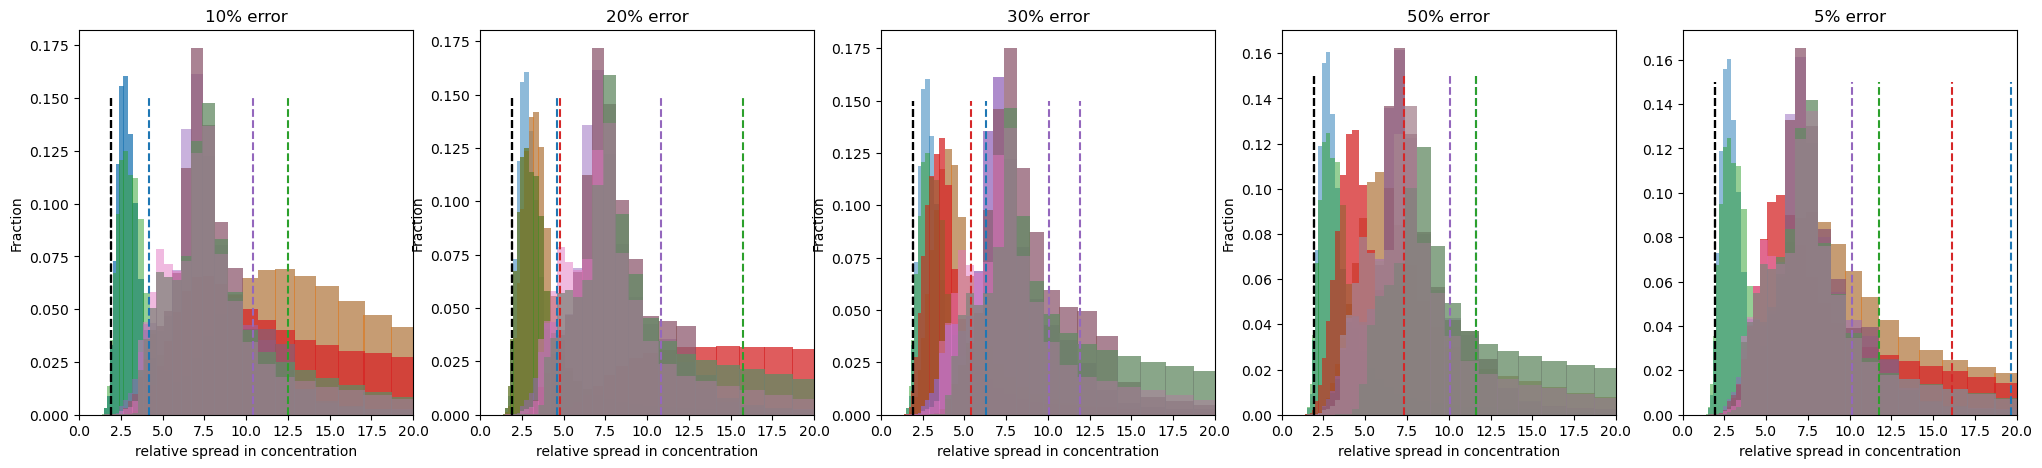

In [356]:
# percentile_idx = 1
# plt_lst = [0,1,2,3,4,5,6,7]
plt_lst = np.arange(len(nc_data_lst))
n_col = 5
n_row = 1
# n_row = int(np.ceil(len(plt_lst)/n_col))

line_height = 0.15
x_lim = 20

conc_log_wid_dct = {}
conc_log_error_dct = {}

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))


fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()

# fig_cdf,ax_lst_cdf = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst_cdf = ax_lst_cdf.ravel()

ax_idx = 0
for m_idx, pidx in enumerate(plt_lst):
    model_str = model_lst[pidx]
    if model_str not in conc_log_wid_dct:
        conc_log_wid_dct[model_str] = []
        conc_log_error_dct[model_str] = []
        plot_zero_error=True
    
    centroid_data_ln = centroid_data_ln_lst[pidx]
    act_data_ln = act_data_ln_lst[pidx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,0]
    percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_ens_delta = percentile_ens_delta[:,0]
    
    # ax = ax_lst[m_idx]
    # hists = np.histogram(percentile_delta,
    #             bins=np.linspace(0,3,50))
    # hists_ens = np.histogram(percentile_ens_delta,
    #             bins=np.linspace(0,3,50))

    ax = ax_lst[ax_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,4,100))
    hists_ens = np.histogram(percentile_ens_delta,
                bins=np.linspace(0,4,100))
    
    x_axis_plt0 = 10**hists[1]
    x_axis_plt = x_axis_plt0[:-1] #(1-10**(hists[1][:-1]))/(1+10**(hists[1][:-1]))

    if plot_zero_error:
        ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(x_axis_plt0),alpha=0.5,facecolor=model_color_dct[model_str])
        ax.plot(2*[10**prior_percentile_delta[0,0]],[0,line_height],'k--')
        ax.set_ylabel(r'Fraction')
        ax.set_xlabel(r'relative spread in concentration')
        ax.set_title(r'0% error')
        ax.set_xlim([0, x_lim])
        ax_idx = (ax_idx+1)%n_col
        ax = ax_lst[ax_idx]
    
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(x_axis_plt0),alpha=0.5,facecolor=model_color_dct[model_str])

    ax.plot(2*[prior_percentile_delta[0,0]],[0,line_height],'k--')

    x_axis_plt0 = 10**hists[1]
    # x_axis_plt0 = (10**(hists[1]-1))/(1+10**(hists[1]))
    x_axis_plt = x_axis_plt0[:-1] #(1-10**(hists[1][:-1]))/(1+10**(hists[1][:-1]))
    # x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(x_axis_plt0),alpha=0.5)
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(x_axis_plt0),alpha=0.5)

    ax.plot(2*[10**prior_percentile_delta[0,0]],[0,line_height],'k--')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")

    ax.set_xlabel(r'relative spread in concentration')
    ax.set_xlim([0, x_lim])
    
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    
    # if m_idx//n_col == n_row-1:
    #     ax.set_xlabel(r'relative spread in concentration')
    # if m_idx%n_col == 0:
    #     ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    # title = custom_label_lst[pidx]
    # ax.set_title(title)
    # ax.set_xlim([0,20])
    # # ax.set_ylim([0,3])

    contain_lim = 1-0.90
    h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
    h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
    cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
    cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])

    if plot_zero_error:
        ax_lst[ax_idx-1].plot(2*[cdf_lim],[0,line_height],'--',color=model_color_dct[model_str])
    ax.plot(2*[cdf_lim_ens],[0,line_height],'--',color=model_color_dct[model_str])
    
    print(title + f"\n{100*(1-contain_lim):.02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]:.02f}")
    if len(conc_log_wid_dct[model_str]) == 0:
        conc_log_wid_dct[model_str].append(cdf_lim)
        conc_log_error_dct[model_str].append(0.0)
    conc_log_wid_dct[model_str].append(cdf_lim_ens)
    conc_log_error_dct[model_str].append(ens_width_lst[pidx])

    ax_idx = (ax_idx+1)%n_col
    plot_zero_error = False

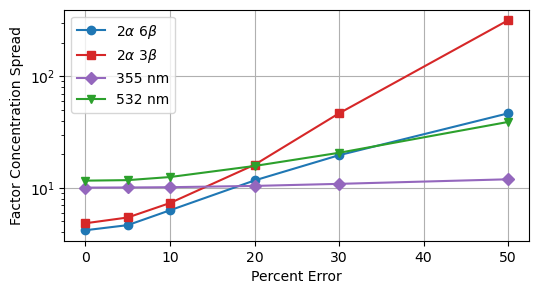

In [357]:
fig,ax = plt.subplots(1,1,figsize=(6,3))

for model_str in conc_log_wid_dct:
    y_data = np.asarray(conc_log_wid_dct[model_str], dtype=float)
    x_data = np.asarray(conc_log_error_dct[model_str], dtype=float)
    label = model_descr_dct[model_str]
    plt_color = model_color_dct[model_str]
    plt_marker = model_marker_dct[model_str]
    ax.plot(x_data*100,y_data,label=label,color=plt_color,marker=plt_marker)

ax.grid(visible=True)
ax.set_xlabel("Percent Error")
ax.set_ylabel("Factor Concentration Spread")
ax.legend()
ax.set_yscale('log')

In [358]:
# percentile_idx = 1
# n_col = 4
# # n_row = int(np.ceil(len(hcmb_lst)/n_col))
# n_row = int(np.ceil(len(plt_lst)/n_col))

# prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))

# rad_log_wid_dct = {}
# rad_log_error_dct = {}

# fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst = ax_lst.ravel()
# fig_cdf,ax_lst_cdf = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
# ax_lst_cdf = ax_lst_cdf.ravel()

# # for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
# for m_idx, pidx in enumerate(plt_lst):
#     model_str = model_lst[pidx]
#     if model_str not in rad_log_wid_dct:
#         rad_log_wid_dct[model_str] = []
#         rad_log_error_dct[model_str] = []
        
#     act_data_ln = act_data_ln_lst[m_idx]
#     percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
#     percentile_delta = percentile_delta[:,1]
#     percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
#     percentile_ens_delta = percentile_ens_delta[:,1]
#     ax = ax_lst[m_idx]
#     hists = np.histogram(percentile_delta,
#                 bins=np.linspace(0,1,50))
#     hists_ens = np.histogram(percentile_ens_delta,
#                 bins=np.linspace(0,1,50))
#     # x_axis_plt = 10**(hists[1][:-1])
#     x_axis_plt = hists[1][:-1]
#     ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]),alpha=0.5)
#     ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(hists_ens[1]),alpha=0.5)

#     ax.plot(2*[prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

#     # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
#     # x_ax_lim = ax.get_xlim()
#     # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
#     #         [prior_percentile_delta[0,0]]*2,
#     #         'k--')
#     # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
#     # ax.set_xscale('log')
#     # ax.set_yscale('log')

#     print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
#     # if m_idx//n_col == 1:
#     if m_idx//n_col == n_row-1:
#         ax.set_xlabel(r'$\log_{10}$ radius spread')
#     if m_idx%n_col == 0:
#         ax.set_ylabel(r'Fraction')
#     # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
#     title = custom_label_lst[pidx]
#     ax.set_title(title)
#     # ax.set_xlim([-3,3])
#     # ax.set_ylim([0,3])
    
#     contain_lim = 1-0.90
#     h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
#     h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
#     cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
#     cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])
#     ax = ax_lst_cdf[m_idx]
#     ax.bar(x_axis_plt,h_cdf,width=np.diff(hists[1]),alpha=0.5)
#     ax.bar(x_axis_plt,h_cdf_ens,width=np.diff(hists_ens[1]),alpha=0.5)

#     ax.plot(2*[prior_percentile_delta[0,1]],[0,1],'k--')
#     ax.plot(2*[cdf_lim],[0,1],'C0--')
#     ax.plot(2*[cdf_lim_ens],[0,1],'C1--')
#     print(title + f"\n{100*(1-contain_lim):02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]}")

#     if len(rad_log_wid_dct[model_str]) == 0:
#         rad_log_wid_dct[model_str].append(cdf_lim)
#         rad_log_error_dct[model_str].append(0.0)
#     rad_log_wid_dct[model_str].append(cdf_lim_ens)
#     rad_log_error_dct[model_str].append(ens_width_lst[pidx])

#     if m_idx//n_col == n_row-1:
#         ax.set_xlabel(r'$\log_{10}$ radius spread')
#     if m_idx%n_col == 0:
#         ax.set_ylabel(r'Cumulative Fraction')

5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %
5-95 %


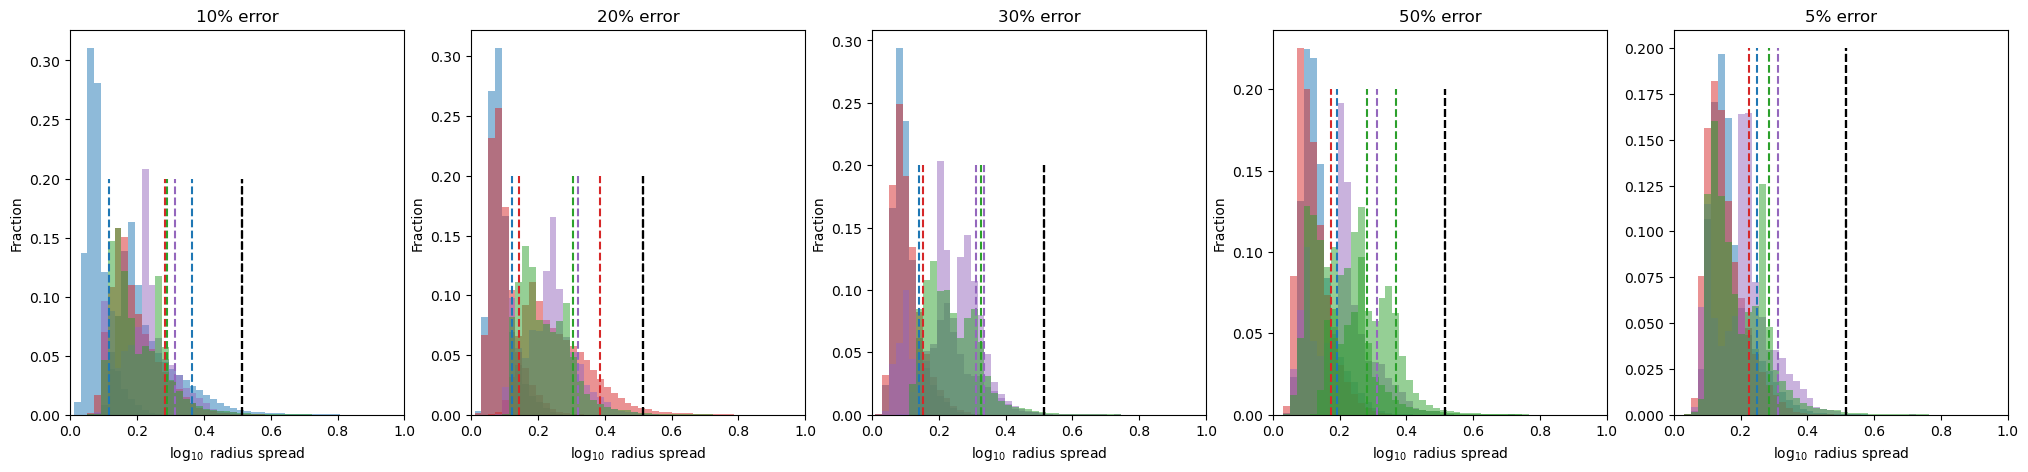

In [359]:
percentile_idx = 1
n_col = 5
n_row = 1
line_height = 0.2

x_lim = 1


prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))

rad_log_wid_dct = {}
rad_log_error_dct = {}

fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()

ax_idx = 0
for m_idx, pidx in enumerate(plt_lst):
    model_str = model_lst[pidx]
    if model_str not in rad_log_wid_dct:
        rad_log_wid_dct[model_str] = []
        rad_log_error_dct[model_str] = []
        plot_zero_error=True
        
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_ens_delta = percentile_ens_delta[:,1]
    ax = ax_lst[ax_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,1,50))
    hists_ens = np.histogram(percentile_ens_delta,
                bins=np.linspace(0,1,50))
    
    # x_axis_plt0 = 10**hists[1]
    x_axis_plt0 = hists[1]
    x_axis_plt = x_axis_plt0[:-1]

    if plot_zero_error:
        ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(x_axis_plt0),alpha=0.5,facecolor=model_color_dct[model_str])
        ax.plot(2*[10**prior_percentile_delta[0,0]],[0,line_height],'k--')
        ax.set_ylabel(r'Fraction')
        ax.set_xlabel(r'$\log_{10}$ radius spread')
        ax.set_title(r'0% error')
        ax.set_xlim([0, x_lim])
        ax_idx = (ax_idx+1)%n_col
        ax = ax_lst[ax_idx]
        
    # ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(hists[1]),alpha=0.5)
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(x_axis_plt0),alpha=0.5,facecolor=model_color_dct[model_str])

    ax.plot(2*[prior_percentile_delta[0,1]],[0,line_height],'k--')

    

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    ax.set_xlabel(r'$\log_{10}$ radius spread')
    ax.set_xlim([0, x_lim])
    
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    
    
    contain_lim = 1-0.90
    h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
    h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
    cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
    cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])

    # ax.bar(x_axis_plt,h_cdf,width=np.diff(hists[1]),alpha=0.5)
    # ax.bar(x_axis_plt,h_cdf_ens,width=np.diff(hists_ens[1]),alpha=0.5)
    
    if plot_zero_error:
        ax_lst[ax_idx-1].plot(2*[cdf_lim],[0,line_height],'--',color=model_color_dct[model_str])
    ax.plot(2*[cdf_lim_ens],[0,line_height],'--',color=model_color_dct[model_str])

    # ax.plot(2*[prior_percentile_delta[0,1]],[0,1],'k--')
    # ax.plot(2*[cdf_lim],[0,1],'C0--')
    # ax.plot(2*[cdf_lim_ens],[0,1],'C1--')
    # print(title + f"\n{100*(1-contain_lim):02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]}")

    if len(rad_log_wid_dct[model_str]) == 0:
        rad_log_wid_dct[model_str].append(cdf_lim)
        rad_log_error_dct[model_str].append(0.0)
    rad_log_wid_dct[model_str].append(cdf_lim_ens)
    rad_log_error_dct[model_str].append(ens_width_lst[pidx])

    ax_idx = (ax_idx+1)%n_col
    plot_zero_error = False

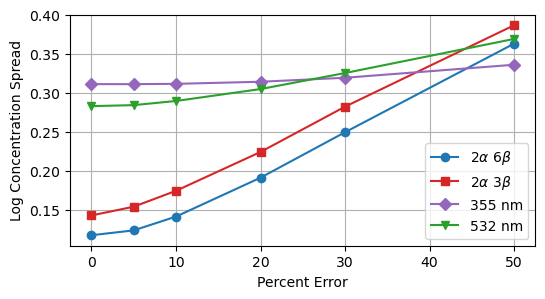

In [360]:
fig,ax = plt.subplots(1,1,figsize=(6,3))

for model_str in rad_log_wid_dct:
    y_data = np.asarray(rad_log_wid_dct[model_str], dtype=float)
    x_data = np.asarray(rad_log_error_dct[model_str], dtype=float)
    label = model_descr_dct[model_str]
    plt_color = model_color_dct[model_str]
    plt_marker = model_marker_dct[model_str]
    ax.plot(x_data*100,y_data,label=label,color=plt_color,marker=plt_marker)

ax.grid(visible=True)
ax.set_xlabel("Percent Error")
ax.set_ylabel("Log Concentration Spread")
ax.legend()

5-95 %
5% error
90.000000%
No Noise: 1.332919817593038
Ensemble: 1.3546920500563873
5-95 %
10% error
90.000000%
No Noise: 1.332919817593038
Ensemble: 1.4094339299419048
5-95 %
20% error
90.000000%
No Noise: 1.332919817593038
Ensemble: 1.5803052510721316
5-95 %
30% error
90.000000%
No Noise: 1.332919817593038
Ensemble: 1.8074316188683732
5-95 %
50% error
90.000000%
No Noise: 1.332919817593038
Ensemble: 2.314633780921524
5-95 %
5% error
90.000000%
No Noise: 1.4166143364617532
Ensemble: 1.4485570149481994
5-95 %
10% error
90.000000%
No Noise: 1.4166143364617532
Ensemble: 1.5190580978652226
5-95 %
20% error
90.000000%
No Noise: 1.4166143364617532
Ensemble: 1.7069085064112148
5-95 %
30% error
90.000000%
No Noise: 1.4166143364617532
Ensemble: 1.9496378076252925
5-95 %
50% error
90.000000%
No Noise: 1.4166143364617532
Ensemble: 2.450859147263331
5-95 %
5% error
90.000000%
No Noise: 2.080650435680957
Ensemble: 2.081043519400006
5-95 %
10% error
90.000000%
No Noise: 2.080650435680957
Ensemble: 

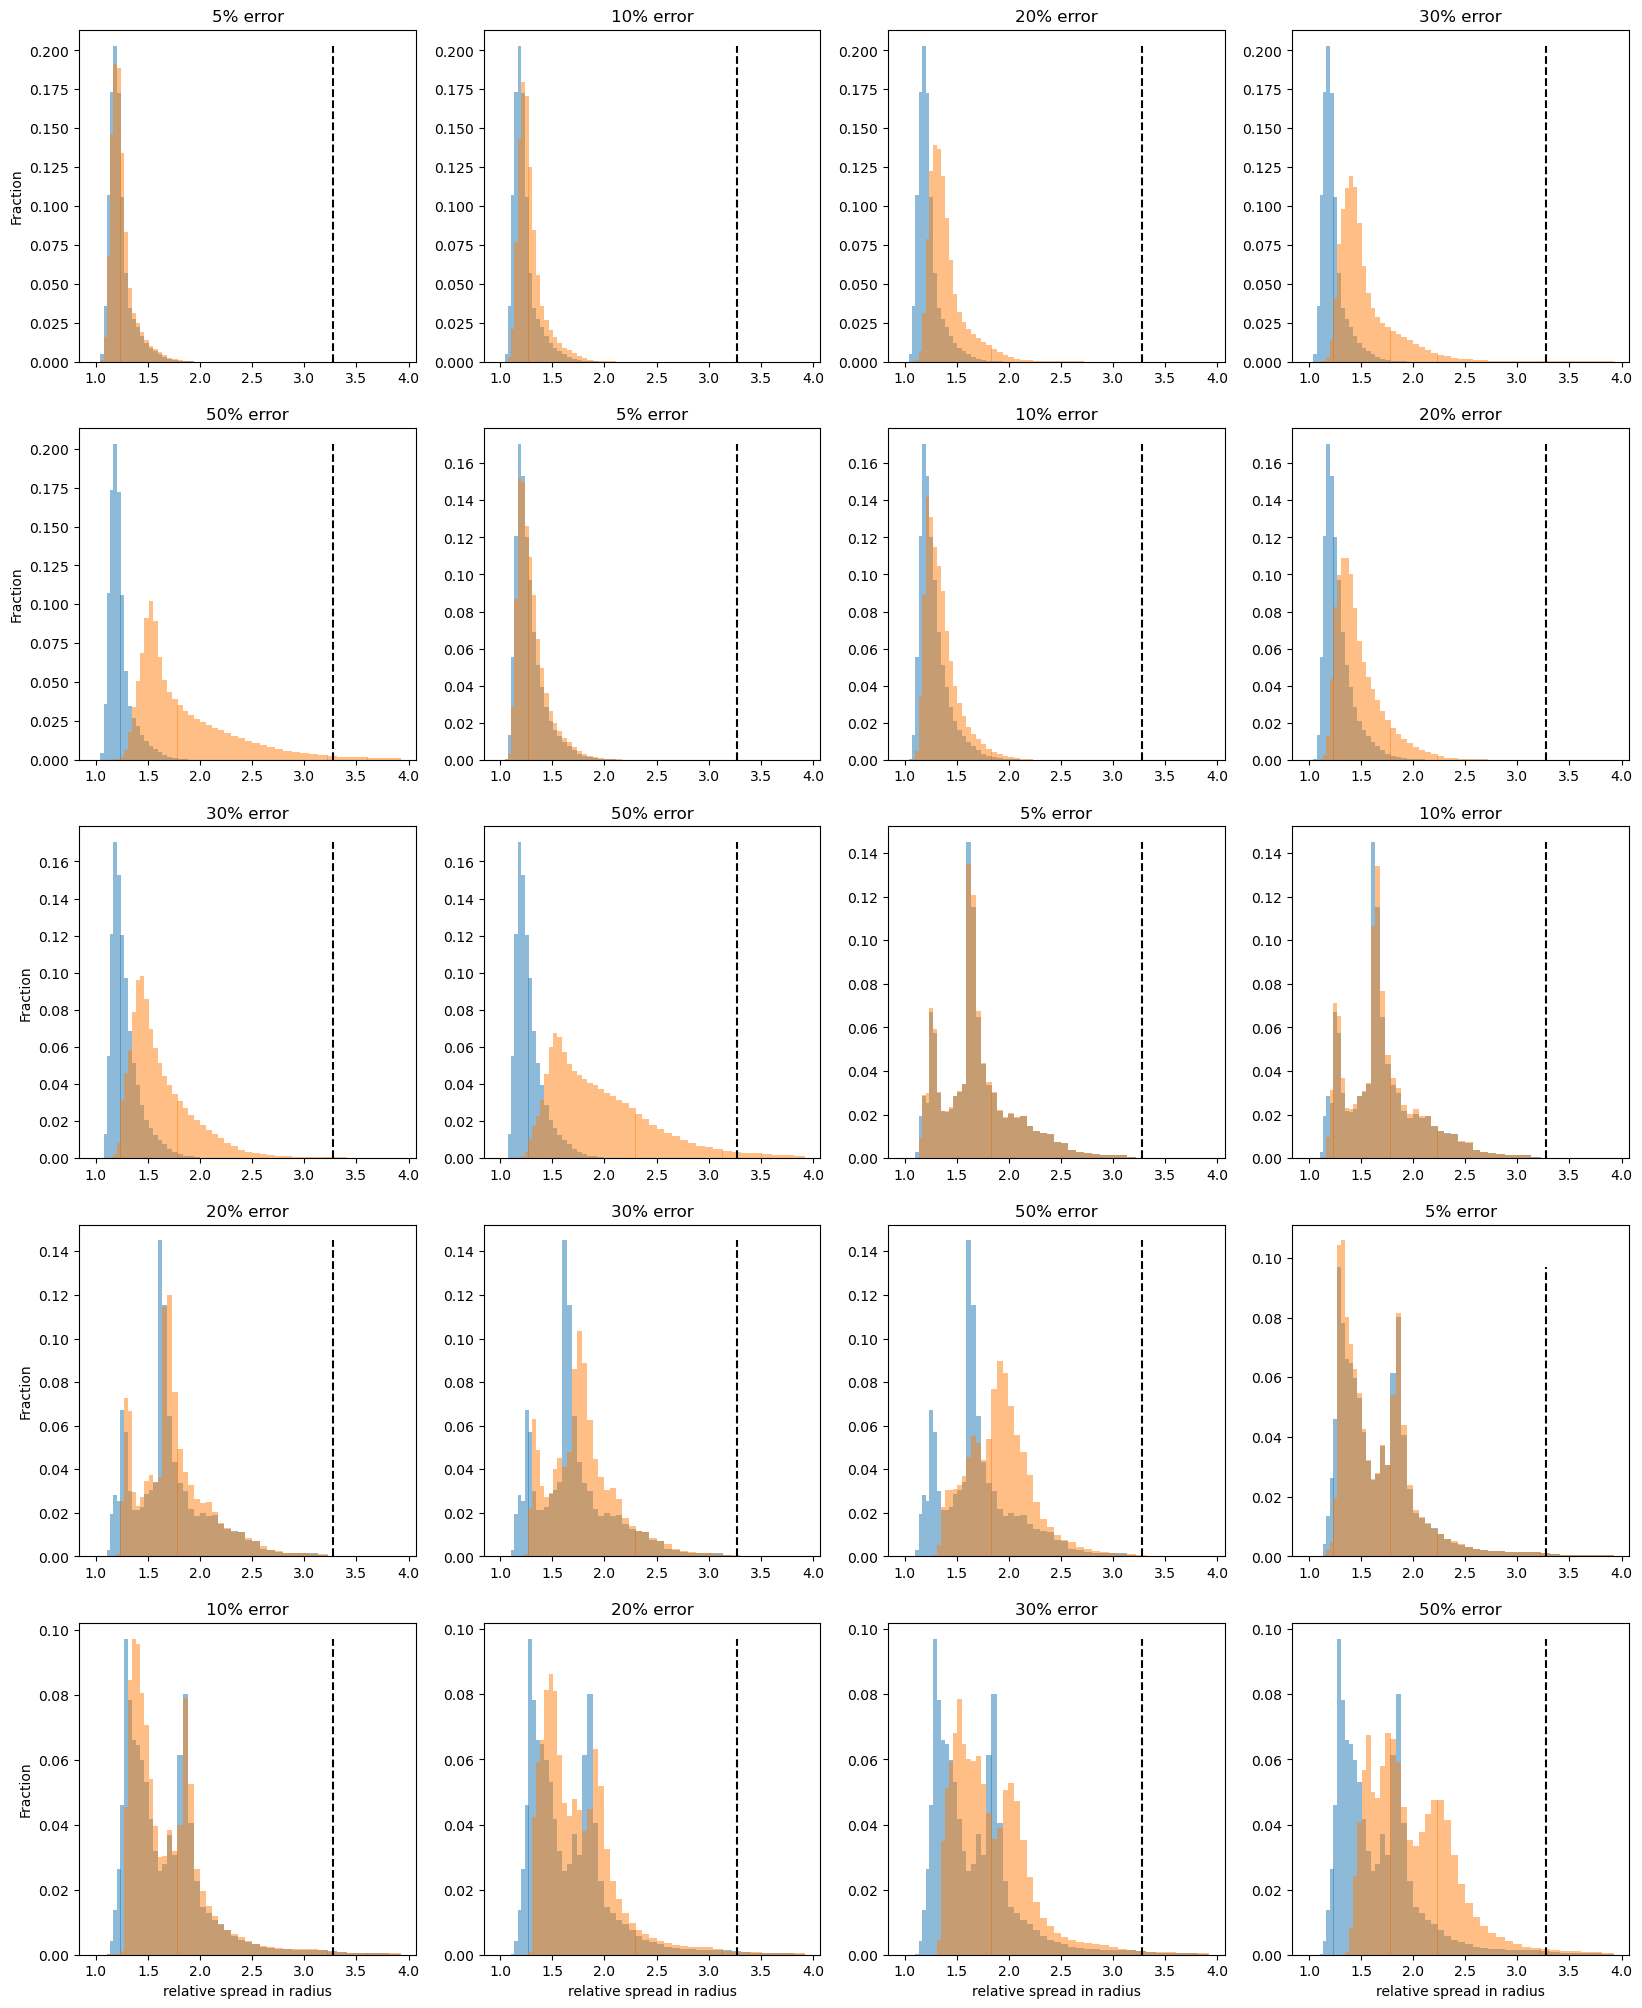

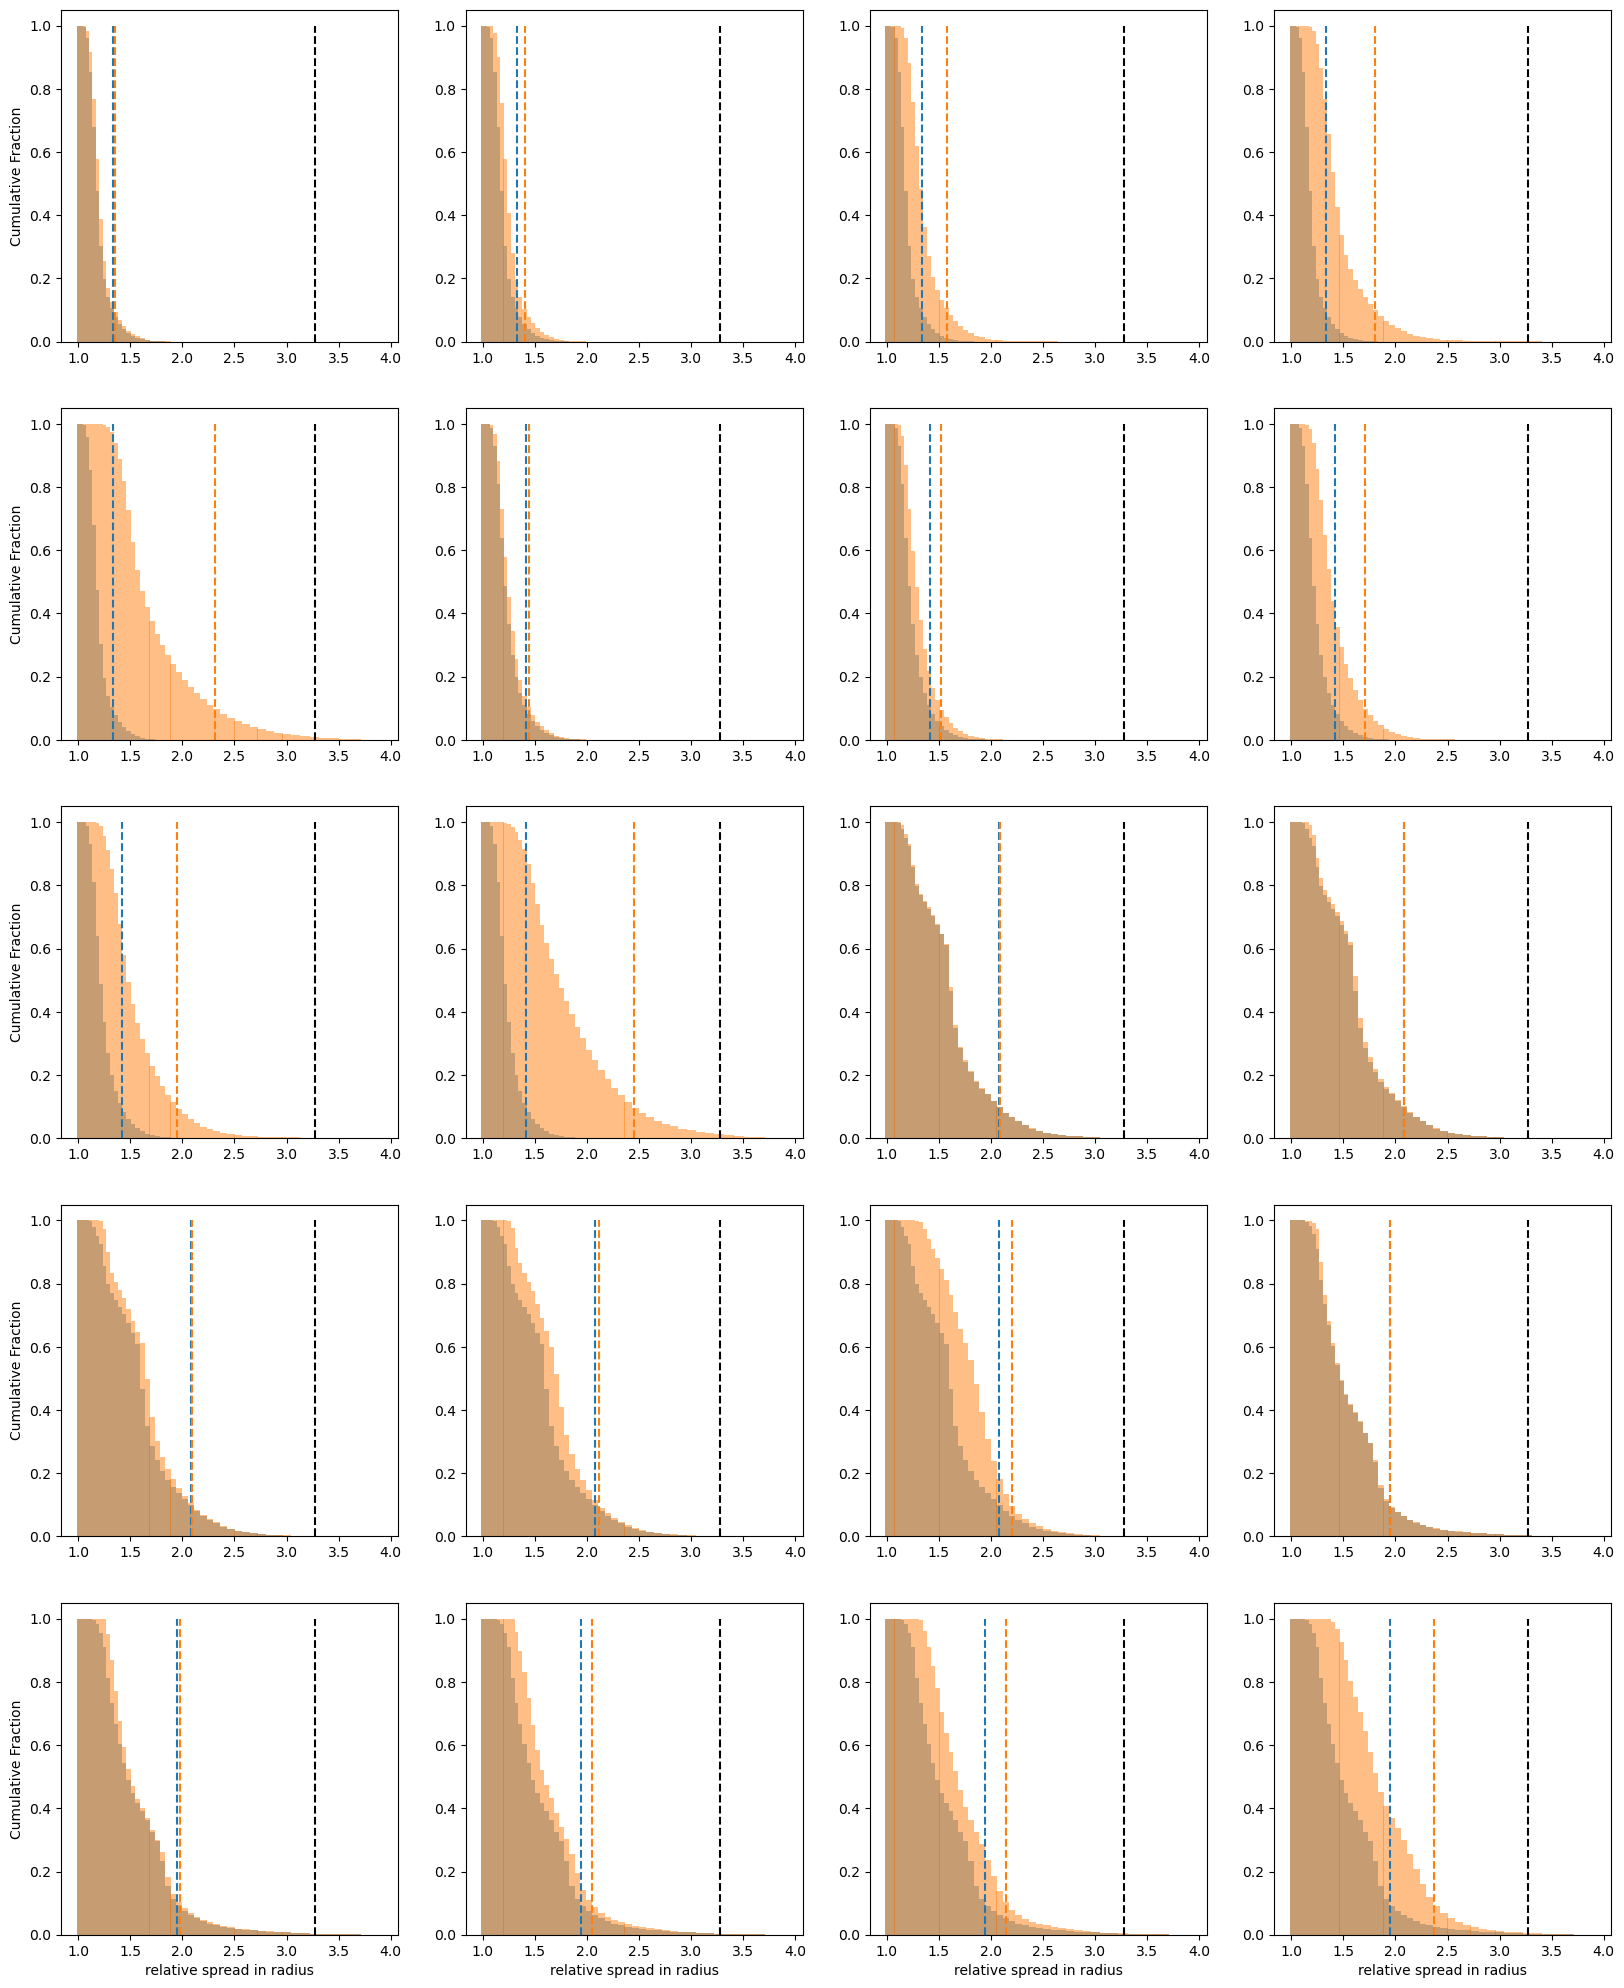

In [361]:
percentile_idx = 1
n_col = 4
# n_row = int(np.ceil(len(hcmb_lst)/n_col))
n_row = int(np.ceil(len(plt_lst)/n_col))

prior_percentile_delta = (percentile_prior_ln_lst[percentile_idx][1]-percentile_prior_ln_lst[percentile_idx][0])*np.log10(np.exp(1))

rad_log_wid_dct = {}
rad_log_error_dct = {}

fig,ax_lst = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst = ax_lst.ravel()

fig_cdf,ax_lst_cdf = plt.subplots(n_row,n_col,figsize=(5*n_col,5*n_row))
ax_lst_cdf = ax_lst_cdf.ravel()

# for m_idx, centroid_data_ln in enumerate(centroid_data_ln_lst):
for m_idx, pidx in enumerate(plt_lst):
    model_str = model_lst[pidx]
    if model_str not in rad_log_wid_dct:
        rad_log_wid_dct[model_str] = []
        rad_log_error_dct[model_str] = []
        
    act_data_ln = act_data_ln_lst[m_idx]
    percentile_delta = (percentile_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_delta = percentile_delta[:,1]
    percentile_ens_delta = (percentile_ens_data_ln_lst_lst[pidx][percentile_idx][1]-percentile_ens_data_ln_lst_lst[pidx][percentile_idx][0])*np.log10(np.exp(1))
    percentile_ens_delta = percentile_ens_delta[:,1]
    ax = ax_lst[m_idx]
    hists = np.histogram(percentile_delta,
                bins=np.linspace(0,0.6,50))
    hists_ens = np.histogram(percentile_ens_delta,
                bins=np.linspace(0,0.6,50))
    x_axis_plt = 10**(hists[1][:-1])
    # x_axis_plt = hists[1][:-1]
    ax.bar(x_axis_plt,hists[0]/np.sum(hists[0]),width=np.diff(10**hists[1]),alpha=0.5)
    ax.bar(x_axis_plt,hists_ens[0]/np.sum(hists_ens[0]),width=np.diff(10**hists_ens[1]),alpha=0.5)

    ax.plot(2*[10**prior_percentile_delta[0,1]],[0,np.max(hists[0])/np.sum(hists[0])],'k--')

    # ax.scatter((np.mean(hist_act_data_ln[:,0])-act_data_ln[:,0])*np.log10(np.exp(1)),[prior_percentile_delta[0,0]]*act_data_ln[:,0].size,s=3)
    # x_ax_lim = ax.get_xlim()
    # ax.plot(np.exp(np.mean(hist_act_data_ln[:,0])-np.exp(act_data_ln[:,0])),
    #         [prior_percentile_delta[0,0]]*2,
    #         'k--')
    # ax.plot([1,1e4],[1,1e4],'k--',linewidth=2)
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    print(f"{(percentile_model_sets[pidx][percentile_idx][0]*100):.0f}-{(percentile_model_sets[pidx][percentile_idx][1]*100):.0f} %")
    
    # if m_idx//n_col == 1:
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'relative spread in radius')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Fraction')
    # title = ', '.join(label_param_lst_lst[pidx])+": "+", ".join(label_wl_lst_lst[pidx])
    title = custom_label_lst[pidx]
    ax.set_title(title)
    # ax.set_xlim([-3,3])
    # ax.set_ylim([0,3])

    contain_lim = 1-0.90
    h_cdf = 1-np.cumsum(hists[0]/np.sum(hists[0]))
    h_cdf_ens = 1-np.cumsum(hists_ens[0]/np.sum(hists_ens[0]))
    cdf_lim = np.interp([contain_lim],h_cdf[::-1],x_axis_plt[::-1])
    cdf_lim_ens = np.interp([contain_lim],h_cdf_ens[::-1],x_axis_plt[::-1])
    ax = ax_lst_cdf[m_idx]
    ax.bar(x_axis_plt,h_cdf,width=np.diff(10**hists[1]),alpha=0.5)
    ax.bar(x_axis_plt,h_cdf_ens,width=np.diff(10**hists_ens[1]),alpha=0.5)

    ax.plot(2*[10**prior_percentile_delta[0,1]],[0,1],'k--')
    ax.plot(2*[cdf_lim],[0,1],'C0--')
    ax.plot(2*[cdf_lim_ens],[0,1],'C1--')
    print(title + f"\n{100*(1-contain_lim):02f}%\nNo Noise: {cdf_lim[0]}\nEnsemble: {cdf_lim_ens[0]}")

    if len(rad_log_wid_dct[model_str]) == 0:
        rad_log_wid_dct[model_str].append(cdf_lim)
        rad_log_error_dct[model_str].append(0.0)
    rad_log_wid_dct[model_str].append(cdf_lim_ens)
    rad_log_error_dct[model_str].append(ens_width_lst[pidx])
    
    if m_idx//n_col == n_row-1:
        ax.set_xlabel(r'relative spread in radius')
    if m_idx%n_col == 0:
        ax.set_ylabel(r'Cumulative Fraction')

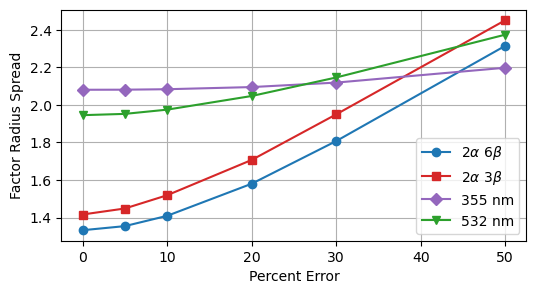

In [362]:
fig,ax = plt.subplots(1,1,figsize=(6,3))

for model_str in rad_log_wid_dct:
    y_data = np.asarray(rad_log_wid_dct[model_str], dtype=float)
    x_data = np.asarray(rad_log_error_dct[model_str], dtype=float)
    label = model_descr_dct[model_str]
    plt_color = model_color_dct[model_str]
    plt_marker = model_marker_dct[model_str]
    ax.plot(x_data*100,y_data,label=label,color=plt_color,marker=plt_marker)

ax.grid(visible=True)
ax.set_xlabel("Percent Error")
ax.set_ylabel("Factor Radius Spread")
ax.legend()
# ax.set_yscale('log')